# 04 RFM Segmentation

# Customer Segmentation Using RFM Analysis

## Introduction

RFM (Recency, Frequency, Monetary) is a customer segmentation technique used to analyze customer purchasing behavior and identify valuable customer groups. It helps businesses understand customer engagement, improve retention strategies, and create targeted marketing campaigns.

The RFM model evaluates customers using three dimensions:

- **Recency (R):** How recently a customer made a purchase.
- **Frequency (F):** How often a customer makes purchases.
- **Monetary (M):** How much money a customer spends.

By combining these three metrics, customers can be grouped into meaningful segments such as loyal customers, high-value customers, inactive customers, and customers at risk of churn.

---

## RFM Metrics

### 1. Recency (R)

Recency measures the number of days since the customer's most recent purchase.

A lower recency value indicates a more active customer.

Formula:

\[
df{Recency} = df{Snapshot Date} - df{Last Purchase Date}
\]

Example:

| Customer | Last Purchase | Recency |
|----------|--------------|---------|
| A | 2026-05-15 | 5 |
| B | 2026-02-10 | 99 |

Interpretation:
- Lower value → Customer purchased recently.
- Higher value → Customer may be inactive.

---

### 2. Frequency (F)

Frequency measures how often a customer makes purchases during the observation period.

Formula:

\[
df{Frequency} = df{Number of Transactions}
\]

Example:

| Customer | Transactions | Frequency |
|----------|-------------|----------|
| A | 12 | 12 |
| B | 3 | 3 |

Interpretation:
- Higher value → More loyal customer.
- Lower value → Occasional customer.

---

### 3. Monetary (M)

Monetary measures the total amount spent by the customer.

Formula:

\[
df{Monetary} = sum df{Transaction Amount}
\]

Example:

| Customer | Total Spend |
|----------|------------|
| A | 1200 |
| B | 250 |

Interpretation:
- Higher value → High-value customer.
- Lower value → Low-spending customer.

---

## RFM Calculation Process

The RFM analysis is performed in the following steps:

1. Prepare and clean transaction data.
2. Select a reference date (Snapshot Date).
3. Group transactions by customer.
4. Calculate:
   - Recency → Days since last purchase
   - Frequency → Number of purchases
   - Monetary → Total spending
5. Convert R, F, and M values into scores.
6. Combine scores to generate customer segments.

---

## Customer Segmentation Examples

| RFM Pattern | Segment | Description |
|------------|---------|-------------|
| High R, High F, High M | Champions | Recent, frequent, and high-spending customers |
| High F, High M | Loyal Customers | Strong repeat customers |
| High R, Low F | New Customers | Recently acquired customers |
| Low R, High F | At Risk | Previously active but inactive recently |
| Low R, Low F, Low M | Lost Customers | Low engagement customers |

---

## Business Value of RFM

RFM segmentation enables businesses to:

- Identify valuable customers.
- Improve customer retention.
- Detect customers likely to churn.
- Personalize marketing campaigns.
- Optimize promotional strategies.
- Increase customer lifetime value (CLV).

This notebook applies the RFM methodology to transaction data in order to generate customer segments and extract actionable business insights.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
# load data
def load_data(file_path):
    df = pd.read_csv(file_path, encoding='ISO-8859-1')
    return df

df = load_data(r"D:\retail-projects\online-retail-analysis\data\processed\online_retail_cleaned.csv")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Year,Month,Day,Revenue,Weekday
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009,2009-12,1,83.4,1
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,2009-12,1,81.0,1
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,2009-12,1,81.0,1
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,2009,2009-12,1,100.8,1
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009,2009-12,1,30.0,1


In [26]:
# filter out negative and zero quantity
df = df[df["Quantity"] > 0]

In [27]:
# drop rows with missing customer_id
df = df.dropna(subset=["Customer ID"])

In [28]:
df.info()

<class 'pandas.DataFrame'>
Index: 779423 entries, 0 to 1026993
Data columns (total 13 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      779423 non-null  str    
 1   StockCode    779423 non-null  str    
 2   Description  779423 non-null  str    
 3   Quantity     779423 non-null  int64  
 4   InvoiceDate  779423 non-null  str    
 5   Price        779423 non-null  float64
 6   Customer ID  779423 non-null  float64
 7   Country      779423 non-null  str    
 8   Year         779423 non-null  int64  
 9   Month        779423 non-null  str    
 10  Day          779423 non-null  int64  
 11  Revenue      779423 non-null  float64
 12  Weekday      779423 non-null  int64  
dtypes: float64(3), int64(4), str(6)
memory usage: 83.3 MB


In [29]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [30]:
# some EDA
# Who are my best 10 customers?
df.groupby("Customer ID")["Quantity"].sum().sort_values(ascending=False).head(10)


Customer ID
14646.0    367193
13902.0    220600
13694.0    188201
18102.0    181645
14156.0    164325
14911.0    147972
17511.0    117174
16684.0    104810
14298.0    100272
12415.0     91447
Name: Quantity, dtype: int64

In [31]:
# Who spends the most?
df["amount"] = df["Quantity"] * df["Price"]
df.groupby("Customer ID")["amount"].sum().sort_values(ascending=False).head(10)

Customer ID
18102.0    580987.04
14646.0    528602.52
14156.0    313437.62
14911.0    291420.81
17450.0    244784.25
13694.0    195640.69
17511.0    172132.87
16446.0    168472.50
16684.0    147142.77
12415.0    144458.37
Name: amount, dtype: float64

In [32]:
def build_rfm_features(df):
    reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

    rfm = (
        df.groupby("Customer ID")
        .agg(
            Recency=(
                "InvoiceDate",
                lambda x: (reference_date - x.max()).days
            ),
            Frequency=(
                "Invoice",
                "nunique"
            ),
            Monetary=(
                "Revenue",
                "sum"
            ),
        )
    )

    return rfm


df_rfm = build_rfm_features(df)
df_rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,4921.53
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


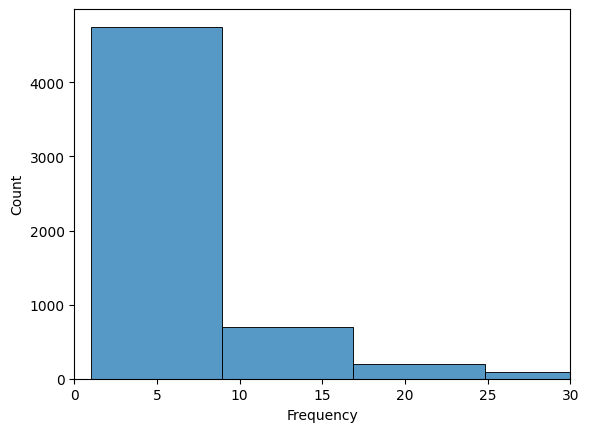

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(
    df_rfm["Frequency"],
    bins=50
)

plt.xlim(0,30)
plt.show()

In [41]:
# Convert raw RFM into scores
def score_rfm(df_rfm):
# Recency (reverse because lower is better)
    df_rfm["R_score"] = (
        pd.qcut(
            df_rfm["Recency"],
            q=5,
            labels=False,
            duplicates="drop"
        )
    )

    # Frequency
    df_rfm["F_score"] = (
        pd.qcut(
            df_rfm["Frequency"],
            q=4,
            labels=False,
            duplicates="drop"
        ) + 1
    )

    # Monetary
    df_rfm["M_score"] = (
        pd.qcut(
            df_rfm["Monetary"],
            q=5,
            labels=False,
            duplicates="drop"
        ) + 1
    )
    return df_rfm

## Handling Duplicate Quantile Boundaries in RFM Scoring

During the RFM scoring process, an issue occurred while assigning customer scores using quantile-based segmentation.

### Problem

The scoring method divides customers into groups based on the distribution of each metric (Recency, Frequency, and Monetary). However, the **Frequency** variable contained many repeated values.

The analysis showed that a large proportion of customers made only a small number of purchases, with many customers purchasing exactly once.

Because of this concentration of repeated values, the quantile calculation produced duplicate boundaries and failed to generate distinct groups.

This indicates that customer purchase behavior is highly skewed, which is a common characteristic in transactional datasets.

---

### Solution

To solve this issue, duplicate quantile boundaries were removed automatically during the scoring process.

Instead of forcing an exact number of equal-sized groups, the segmentation procedure adapts to the actual data distribution and creates only valid score ranges.

This allows the RFM scoring process to continue successfully even when customer purchase frequencies are concentrated in a few values.

---

### Result

After applying this adjustment:

- RFM scores were generated successfully.
- Customer groups became more representative of real purchasing behavior.
- The segmentation process became more robust to skewed distributions.
- The analysis remained suitable for identifying customer value and engagement patterns.

This type of adjustment is common in customer analytics because real-world purchasing behavior rarely follows a perfectly balanced distribution.

In [49]:
# Assign segments based on RFM scores
def assign_rfm_segment(row):
    r = int(row["R_score"])
    f = int(row["F_score"])
    m = int(row["M_score"])

    if r == 5 and f == 4 and m == 5:
        return "Best Customers"
    elif r >= 4 and f >= 3 and m >= 4:
        return "Loyal Customers"
    elif r >= 3 and f >= 2 and m >= 3:
        return "Potential Loyalists"
    elif r >= 2 and f >= 1 and m >= 2:
        return "Needs Attention"
    else:
        return "At Risk"

In [50]:
# add segment column
def add_rfm_segments(scored_rfm: pd.DataFrame) -> pd.DataFrame:
    segmented = scored_rfm.copy()

    segmented["Segment"] = segmented.apply(
        assign_rfm_segment,
        axis=1
    )

    return segmented

In [ ]:
def run_rfm_pipeline(rfm: pd.DataFrame) -> pd.DataFrame:
    """
    Run complete RFM workflow:
    1. Calculate RFM scores
    2. Assign customer segments
    """

    scored = score_rfm(rfm)

    segmented = add_rfm_segments(scored)

    return segmented

In [52]:
df_rfm = run_rfm_pipeline(df_rfm)

df_rfm.head()

Index(['Recency', 'Frequency', 'Monetary', 'R_score', 'F_score', 'M_score'], dtype='str')


,Recency,Frequency,Monetary,R_score,F_score,M_score,Segment
Customer ID,,,,,,,
12346.0,326,12,77556.46,3,3,5,Potential Loyalists
12347.0,2,8,4921.53,0,3,5,At Risk
12348.0,75,5,2019.40,2,2,4,Needs Attention
12349.0,19,4,4428.69,0,2,5,At Risk
12350.0,310,1,334.40,3,1,2,Needs Attention
